In [1]:
#Anna Wojciechowska, Oslo, October 2026
#data source:
#https://archive.ics.uci.edu/dataset/291/airfoil+self+noise
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
airfoil = fetch_ucirepo(id=291)
X = airfoil.data.features
y = airfoil.data.targets
df = X.join(y)
df.to_csv('uci_airfoil_data.csv', index = False)

In [3]:
#since chord -lengt values are in 6 groups corresponding to different airwings models, 
#this value will be used as categorical
print(df["chord-length"].unique()) 
df["chord"] = df["chord-length"].astype("category")

[0.3048 0.2286 0.1524 0.0508 0.0254 0.1016]


In [4]:
#categorical values requires special treatement - dummy encoding
dummies = pd.get_dummies(df["chord"], prefix="dummy_chord_category", drop_first=True, dtype=float)
df = df.join(dummies)
#tutaj do i need it
DUMMY = list(dummies.columns)
df.head()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure,chord,dummy_chord_category_0.0508,dummy_chord_category_0.1016,dummy_chord_category_0.1524,dummy_chord_category_0.2286,dummy_chord_category_0.3048
0,800,0.0,0.3048,71.3,0.002663,126.201,0.3048,0.0,0.0,0.0,0.0,1.0
1,1000,0.0,0.3048,71.3,0.002663,125.201,0.3048,0.0,0.0,0.0,0.0,1.0
2,1250,0.0,0.3048,71.3,0.002663,125.951,0.3048,0.0,0.0,0.0,0.0,1.0
3,1600,0.0,0.3048,71.3,0.002663,127.591,0.3048,0.0,0.0,0.0,0.0,1.0
4,2000,0.0,0.3048,71.3,0.002663,127.461,0.3048,0.0,0.0,0.0,0.0,1.0


In [5]:
#split data
train_idx, test_idx = train_test_split(
    df.index, test_size=1/3, random_state=13, stratify=df["chord"]
)
df["train"] = df.index.isin(train_idx)   
# seee if chords have same representation in both train and test (train !=True) set
pd.crosstab(df["chord"], df["train"], normalize="columns").round(2)

train,False,True
chord,,
0.0254,0.19,0.18
0.0508,0.16,0.16
0.1016,0.18,0.17
0.1524,0.18,0.18
0.2286,0.18,0.18
0.3048,0.13,0.12


In [6]:
#double check if size of train and test  2:1
df[df.train == True].shape, df[df.train == False].shape, df.shape

((1002, 13), (501, 13), (1503, 13))

In [7]:
df.columns

Index(['frequency', 'attack-angle', 'chord-length', 'free-stream-velocity',
       'suction-side-displacement-thickness', 'scaled-sound-pressure', 'chord',
       'dummy_chord_category_0.0508', 'dummy_chord_category_0.1016',
       'dummy_chord_category_0.1524', 'dummy_chord_category_0.2286',
       'dummy_chord_category_0.3048', 'train'],
      dtype='str')

In [8]:
NUM = ["frequency", "attack-angle", "free-stream-velocity",
       "suction-side-displacement-thickness"]
DUMMY = [c for c in df.columns if c.startswith("dummy_")]
PRED = NUM + DUMMY          
OUT = "scaled-sound-pressure"

train = df[df["train"]]
test  = df[~df["train"]]

mu = train[PRED].mean()
sd = train[PRED].std()

X_train = (train[PRED] - mu) / sd
X_test  = (test[PRED]  - mu) / sd
y_train = train[OUT].to_numpy()
y_test  = test[OUT].to_numpy()

In [9]:
len(X_test)

501

$$\hat y_i = \beta_0 \cdot 1 + \beta_1 x_{i1} + \dots + \beta_p x_{ip}$$

In [10]:
# adding intercept column initialized to 1
Xtr = np.column_stack([np.ones(len(X_train)), X_train.to_numpy()])
Xte = np.column_stack([np.ones(len(X_test)),  X_test.to_numpy()])

# LS estimate
XtX_inv = np.linalg.inv(Xtr.T @ Xtr)
beta = XtX_inv @ Xtr.T @ y_train


In [ ]:
#tutaj check me

$$\hat\beta^{LS} = \arg\min_\beta \underbrace{\sum_{i=1}^N \Big(y_i - \beta_0 - \sum_{j=1}^p x_{ij}\beta_j\Big)^2}_{\text{RSS: how well the model fits the data}}$$

In [11]:
# predictions
y_pred_train = Xtr @ beta
y_pred_test  = Xte @ beta

# errors

mse_train = np.mean((y_train - y_pred_train)**2)
mse_test  = np.mean((y_test - y_pred_test)**2)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
#residual sum of squarels
rss  = np.sum((y_test - y_pred_test)**2)

#r2_test   = 1 - np.sum((yte - y_pred_test)**2) / np.sum((yte - yte.mean())**2)

print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
#re
print("rss", rss)


Train RMSE: 4.9304
Test RMSE: 4.3994
rss 9696.509950978556


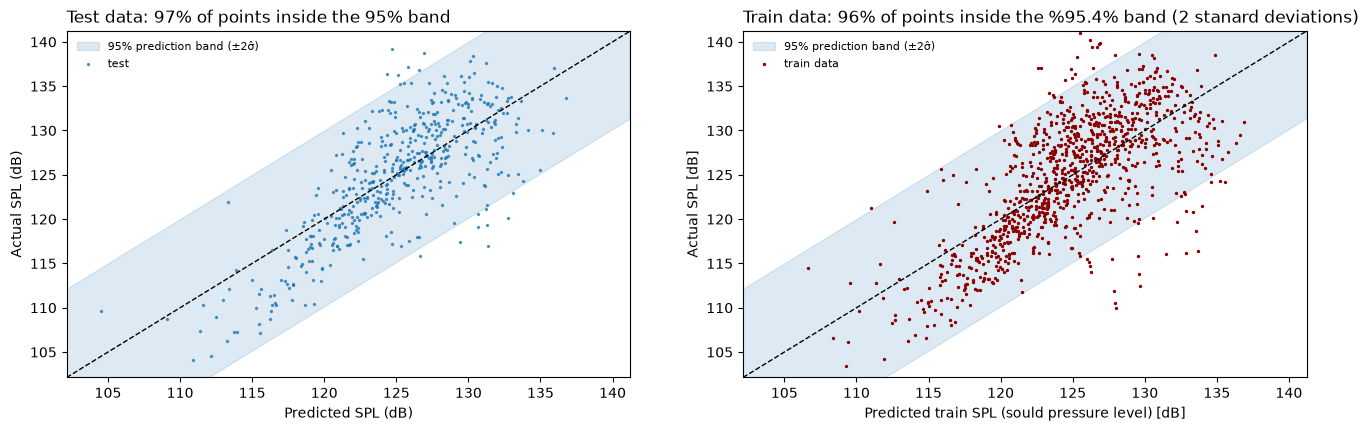

In [31]:
N, p = Xtr.shape
sigma = np.sqrt(np.sum((y_train - y_pred_train)**2) / (N - p -1))   # noise sd,slide 8 lecture 2
res_test = y_test - y_pred_test
res_train = y_train - y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

ax = axes[0]
lims = np.array([min(y_test.min(), y_pred_test.min()) - 2, max(y_test.max(), y_pred_test.max()) + 2])
ax.fill_between(lims, lims - 2*sigma, lims + 2*sigma, color="C0", alpha=0.15, label="95% prediction band (±2σ̂)")
#ax.scatter(y_pred_train, y_train, s=6, c="0.75", label="train")
ax.scatter(y_pred_test, y_test, s=2, c="C0", alpha=0.7, label="test")
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
inside = np.mean(np.abs(res_test) < 2*sigma)
ax.set_xlabel("Predicted SPL (dB)"); ax.set_ylabel("Actual SPL (dB)")
ax.set_title(f"Test data: {inside:.0%} of points inside the 95% band", loc="left")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
lims = np.array([min(y_test.min(), y_pred_test.min()) - 2, max(y_test.max(), y_pred_test.max()) + 2])
ax.fill_between(lims, lims - 2*sigma, lims + 2*sigma, color="C0", alpha=0.15, label="95% prediction band (±2σ̂)")
ax.scatter(y_pred_train, y_train, s=2, c="darkred", label="train data")
#ax.scatter(y_pred_test, y_test, s=12, c="C0", alpha=0.7, label="test")
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
inside = np.mean(np.abs(res_train) < 2*sigma)
ax.set_xlabel("Predicted train SPL (sould pressure level) [dB]"); ax.set_ylabel("Actual SPL [dB]")
ax.set_title(f"Train data: {inside:.0%} of points inside the %95.4% band (2 stanard deviations)", loc="left")
ax.legend(frameon=False, fontsize=8)


,beta,se,z
intercept,124.775,0.157,796.676
frequency,-4.082,0.173,-23.638
attack-angle,-2.809,0.339,-8.280
free-stream-velocity,1.587,0.161,9.848
suction-side-displacement-thickness,-1.524,0.299,-5.089
dummy_chord_category_0.0508,-0.721,0.210,-3.438
dummy_chord_category_0.1016,-1.300,0.247,-5.261
dummy_chord_category_0.1524,-2.623,0.249,-10.524
dummy_chord_category_0.2286,-3.099,0.242,-12.780
dummy_chord_category_0.3048,-3.480,0.236,-14.771


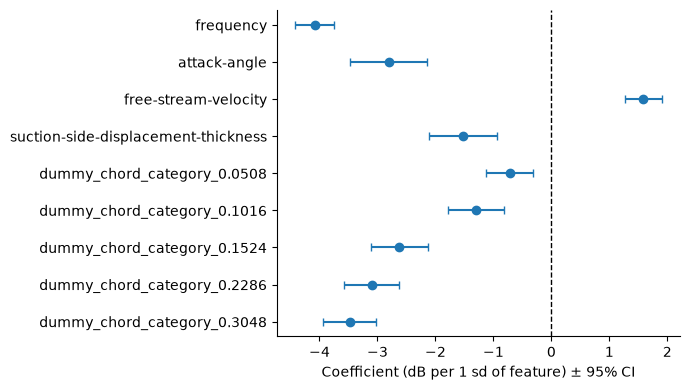

In [32]:
se = sigma * np.sqrt(np.diag(XtX_inv))
names = ["intercept"] + PRED

coef = pd.DataFrame({"beta": beta, "se": se, "z": beta / se}, index=names).round(3)
display(coef)

c = coef.drop("intercept")
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(c["beta"], range(len(c)), xerr=1.96*c["se"], fmt="o", c="C0", capsize=3)
ax.axvline(0, c="k", ls="--", lw=1)
ax.set_yticks(range(len(c)), c.index); ax.invert_yaxis()
ax.set_xlabel("Coefficient (dB per 1 sd of feature) ± 95% CI")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()#implement ridge